# 10 — Model comparison & Walk-forward CV trên Val (Test vẫn niêm phong)

**Bước 4: chốt *giao thức đánh giá* trên Train+Val, chưa mở Test.** Ba việc, đúng thứ tự:
1. **Nhắc lại split 3 phần** + **bộ metric** đúng cho fraud cực mất cân bằng.
2. **So model** LightGBM (đã khoá, ADR-003) vs XGBoost (learning baseline) trên **cùng feature, cùng split — chấm trên VAL**.
3. **Walk-forward CV theo thời gian + embargo** để đọc *phân phối* PR-AUC (mean ± std), cộng lát cắt **warm/cold**. Mọi fold CV nằm trong Train+Val (cửa sổ test rộng nhất `(540,595]` ≤ 631) — **CV không đọc Test**.

> **Kỷ luật data-centric: Test (`step ≥ 632`) niêm phong tới nb12.** Notebook này KHÔNG đọc Test ở bất kỳ đâu — mọi so sánh model, chọn ngưỡng, metric, đường PR/ROC đều trên **Val**. Test chỉ mở **một lần** ở nb12 để báo cáo cuối. Nếu chấm model/feature trên Test rồi mới chọn = peek, điểm đẹp giả.

> **Vì sao đứng TRƯỚC Optuna (nb11):** tuning cần một *thước đo ổn định* để tối ưu. Walk-forward CV ở đây định nghĩa **chính các fold** mà nb11 tối ưu PR-AUC trung bình lên.

> **Exploratory / non-promotable.** Bản chốt chạy `training/` với manifest + đa seed. Mọi run gắn `stage=cv`, experiment `paysim-notebook-modeling`.

**Feature:** lõi 7 PIT-safe (`DEPLOYABLE_CORE`) từ ablation nb09. Model dùng **baseline params** (chưa tuned) — đo giao thức trước, tối ưu sau.

📖 **Cell dưới — Setup** qua `notebook_lab`: resolve đường dẫn Gold/labels, `DEPLOYABLE_CORE`, `PIT12`. In `READY`.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

from pit_fintech.models.notebook_lab import DEPLOYABLE_CORE, PIT12, resolve_lab_paths

paths = resolve_lab_paths()
READY = paths.ready
print(paths.as_dict())

{'paysim_csv': True, 'silver_transactions': True, 'labels': True, 'ready': True}


## Execution control
📖 **Cell dưới.** `RUN` gate phần nặng. `FEATURES` = 7 lõi PIT-safe. `BASELINE_PARAMS` = LightGBM *chưa tuned* (tuning là việc của nb11). `CUTS/TEST_WIDTH/EMBARGOS` định nghĩa giao thức walk-forward mà nb11 sẽ tái dùng.

In [2]:
RUN = True
SEED = 20_260_727
from pit_fintech.models.notebook_lab import load_selected_features

FEATURES = load_selected_features(
    DEPLOYABLE_CORE
)  # bo feature chot o nb09 (fallback DEPLOYABLE_CORE neu chua chay nb09)
print(f"FEATURES ({len(FEATURES)}) = {FEATURES}")

# Baseline (CHUA tuned) — L2=1.0 + scale_pos_weight sqrt(neg/pos) da validate o buoc so-model.
BASELINE_PARAMS = dict(
    n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50, reg_lambda=1.0
)
# Giao thuc walk-forward dung chung voi nb11 (import tu notebook_lab de khong lech).
from pit_fintech.models.notebook_lab import DEFAULT_CUTS, DEFAULT_TEST_WIDTH

CUTS = list(DEFAULT_CUTS)
TEST_WIDTH = DEFAULT_TEST_WIDTH
EMBARGOS = [0, 168]  # 0 = production-realistic, 168 = bao thu (dem 1 tuan)

LOG_TO_MLFLOW = True
print(f"{len(FEATURES)} feats | cuts={CUTS} | test_width={TEST_WIDTH} | embargos={EMBARGOS}")

FEATURES (6) = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_amount_168h', 'pit_distinct_senders_168h']
6 feats | cuts=[360, 420, 480, 540] | test_width=55 | embargos=[0, 168]


## Phần A · Split thời gian & bộ metric

📖 **Vì sao TEMPORAL split, không random?** Bài toán là *dự đoán tương lai từ quá khứ*. Trộn ngẫu nhiên → giao dịch tương lai lọt vào train → điểm đẹp giả, không phản ánh production. Ta chia 3 phần theo `step`: **train** `≤520` (fit) · **val** `521–631` (chọn ngưỡng, so model) · **test** `≥632` (báo cáo một lần ở nb12).

📖 **Cell dưới — Nạp `frame` + dựng 3 split** qua `notebook_lab` và in prevalence mỗi phần (cực thấp → gốc rễ của mọi lựa chọn metric).

In [3]:
frame = splits = None
if RUN and READY:
    from pit_fintech.models.notebook_lab import load_modeling_frame, three_way_temporal_split

    frame = load_modeling_frame(paths)
    splits = three_way_temporal_split(frame)
    train_df, val_df = splits["train"], splits["val"]  # splits["test"] SEALED until nb12
    rows = [
        {
            "split": s,
            "rows": len(p),
            "fraud": int(p["isFraud"].sum()),
            "prevalence": round(int(p["isFraud"].sum()) / max(len(p), 1), 6),
        }
        for s, p in splits.items()
    ]
    display(pd.DataFrame(rows))
    print(f"rows={len(frame):,} | step range=[{frame['step'].min()},{frame['step'].max()}]")
else:
    print("Skipped: set RUN = True (va data READY).")

,split,rows,fraud,prevalence
0,train,2653729,5781,0.002178
1,val,78701,1180,0.014993
2,test,37979,1252,0.032966


rows=2,770,409 | step range=[1,743]


## Phần B · So model LightGBM vs XGBoost (công bằng)

📖 **Cell dưới — Train 2 model trên cùng feature/split** với baseline params. Hai chỉnh để so *đúng*: `scale_pos_weight = √(neg/pos)` (thay vì `neg/pos` gây bão hoà xác suất) áp giống nhau; `reg_lambda=1.0` cho cả hai (khớp L2). XGBoost import graceful (chưa trong deps thì chỉ chạy LightGBM). Ra `proba[model][split]`.

In [4]:
proba = {}
models = {}
if splits is not None:
    import lightgbm as lgb

    pos = int((train_df["isFraud"] == 1).sum())
    neg = int((train_df["isFraud"] == 0).sum())
    spw = float(np.sqrt(neg / max(pos, 1)))
    Xtr, ytr = train_df[FEATURES], train_df["isFraud"]

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=spw,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
        **BASELINE_PARAMS,
    )
    lgbm.fit(Xtr, ytr)
    models["LightGBM"] = lgbm

    try:
        import xgboost as xgb

        xgbm = xgb.XGBClassifier(
            objective="binary:logistic",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=5,
            reg_lambda=1.0,
            scale_pos_weight=spw,
            tree_method="hist",
            eval_metric="aucpr",
            random_state=SEED,
            n_jobs=-1,
        )
        xgbm.fit(Xtr, ytr)
        models["XGBoost"] = xgbm
    except ImportError:
        print("xgboost chua cai -> chi LightGBM. `uv add --group dev xgboost` roi `uv sync`.")

    for mname, mdl in models.items():
        proba[mname] = {s: mdl.predict_proba(part[FEATURES])[:, 1] for s, part in splits.items()}
    print(f"trained: {list(models)} | scale_pos_weight={spw:.2f}")
else:
    print("Skipped: enable RUN above.")

trained: ['LightGBM', 'XGBoost'] | scale_pos_weight=21.40


## 📖 Bộ metric — vì sao PR-AUC là số một
Fraud ~0.3% nên **accuracy bị cấm** (AGENTS §9: đoán "sạch" đã 99.7% đúng). Bộ metric:
- **Không ngưỡng (chất lượng xếp hạng):** `pr_auc` (**chính** — chỉ nhìn lớp fraud, sàn = prevalence), `roc_auc` (lạc quan khi mất cân bằng — đừng bị lừa), `log_loss`/`brier` (calibration của xác suất).
- **Có ngưỡng:** precision/recall/F1 tại một ngưỡng — chọn ngưỡng **trên VAL** (FPR=1%, điểm vận hành dự án) rồi *áp sang* TEST.
- **Nghiệp vụ:** `recall_at_fpr` (giữ báo động giả ≤1%) và `precision@k / recall@k` (chỉ soi top-k mỗi kỳ).

In [5]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


def threshold_free(y, p):
    return {
        "pr_auc": round(float(average_precision_score(y, p)), 6),
        "roc_auc": round(float(roc_auc_score(y, p)), 6),
        "log_loss": round(float(log_loss(y, p, labels=[0, 1])), 6),
        "brier": round(float(brier_score_loss(y, p)), 6),
    }


def at_threshold(y, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {
        "threshold": round(float(thr), 6),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "precision": round(float(precision_score(y, yhat, zero_division=0)), 6),
        "recall": round(float(recall_score(y, yhat, zero_division=0)), 6),
        "f1": round(float(f1_score(y, yhat, zero_division=0)), 6),
    }


def recall_at_fpr(y, p, target_fpr=0.01):
    """Nguong lon nhat giu FPR <= target; fallback quantile khi diem bi ties/saturation."""
    y, p = np.asarray(y), np.asarray(p)
    fpr, tpr, thr = roc_curve(y, p)
    ok = np.where(fpr <= target_fpr)[0]
    i = int(ok[-1]) if len(ok) else 0
    t, rec = float(thr[i]), float(tpr[i])
    if not np.isfinite(t):
        neg = p[y == 0]
        t = float(np.quantile(neg, 1 - target_fpr))
        rec = float(((p >= t) & (y == 1)).sum() / max(int((y == 1).sum()), 1))
    return {"target_fpr": target_fpr, "threshold": t, "recall_at_fpr": round(rec, 6)}


def pr_at_k(y, p, k_frac):
    y, p = np.asarray(y), np.asarray(p)
    k = max(1, int(len(p) * k_frac))
    idx = np.argsort(-p)[:k]
    hit = int(y[idx].sum())
    return {
        "k_frac": k_frac,
        "k": k,
        "precision_at_k": round(hit / k, 6),
        "recall_at_k": round(hit / max(int(y.sum()), 1), 6),
    }

📖 **Cell dưới — Bảng metric KHÔNG ngưỡng trên VAL** cho mỗi model (nhìn `pr_auc` trước). Test niêm phong tới nb12.

In [6]:
free_table = None
if proba:
    yval = splits["val"]["isFraud"].to_numpy()
    free_table = (
        pd.DataFrame([{"model": m, **threshold_free(yval, proba[m]["val"])} for m in proba])
        .sort_values("pr_auc", ascending=False)
        .reset_index(drop=True)
    )
    display(free_table)
else:
    print("Skipped: enable RUN above.")

,model,pr_auc,roc_auc,log_loss,brier
0,XGBoost,0.299476,0.851417,0.115894,0.032447
1,LightGBM,0.259778,0.840275,0.142530,0.033463


📖 **Cell dưới — Metric CÓ ngưỡng, TẤT CẢ trên VAL.** Ngưỡng chọn trên VAL tại FPR=1% rồi báo cáo confusion matrix + P/R/F1 cũng trên VAL. Đúng kỷ luật: so model không đụng Test.

In [7]:
thr_table = None
if proba:
    # Chon nguong tren VAL va bao cao confusion matrix tren VAL (Test niem phong toi nb12).
    yval = splits["val"]["isFraud"].to_numpy()
    rows = []
    for m in proba:
        sel = recall_at_fpr(yval, proba[m]["val"], target_fpr=0.01)
        rows.append({"model": m, **at_threshold(yval, proba[m]["val"], sel["threshold"])})
    thr_table = pd.DataFrame(rows)
    display(thr_table)
else:
    print("Skipped: enable RUN above.")

,model,threshold,TP,FP,FN,TN,precision,recall,f1
0,LightGBM,0.652540,314,715,866,76806,0.305151,0.266102,0.284292
1,XGBoost,0.600399,325,775,855,76746,0.295455,0.275424,0.285088


📖 **Cell dưới — Đường PR & ROC trên VAL** (PR là cái đáng nhìn nhất) + **bảng ngân sách** precision@k/recall@k trên VAL cho top 0.1%/0.5%/1%.

,model,k_frac,k,precision_at_k,recall_at_k
0,LightGBM,0.001,78,0.858974,0.056780
1,LightGBM,0.005,393,0.590331,0.196610
2,LightGBM,0.010,787,0.368488,0.245763
3,XGBoost,0.001,78,1.000000,0.066102
4,XGBoost,0.005,393,0.646310,0.215254
5,XGBoost,0.010,787,0.372300,0.248305


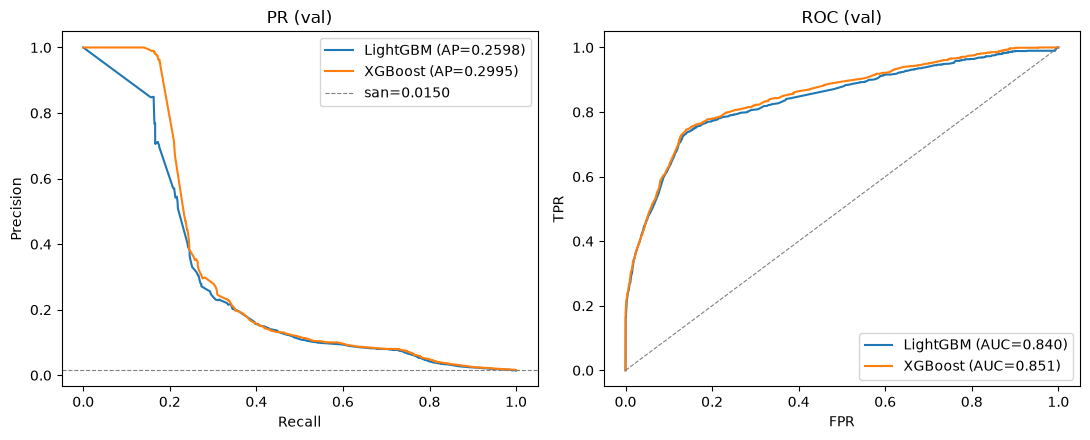

In [8]:
if proba:
    yval = splits["val"]["isFraud"].to_numpy()
    budget = pd.DataFrame(
        [
            {"model": m, **pr_at_k(yval, proba[m]["val"], k)}
            for m in proba
            for k in (0.001, 0.005, 0.01)
        ]
    )
    display(budget)
    try:
        import matplotlib.pyplot as plt

        prevalence = yval.mean()
        fig, (axpr, axroc) = plt.subplots(1, 2, figsize=(11, 4.5))
        for m in proba:
            pr, rc, _ = precision_recall_curve(yval, proba[m]["val"])
            axpr.plot(
                rc, pr, label=f"{m} (AP={average_precision_score(yval, proba[m]['val']):.4f})"
            )
            fpr, tpr, _ = roc_curve(yval, proba[m]["val"])
            axroc.plot(fpr, tpr, label=f"{m} (AUC={roc_auc_score(yval, proba[m]['val']):.3f})")
        axpr.axhline(prevalence, ls="--", c="grey", lw=0.8, label=f"san={prevalence:.4f}")
        axpr.set_xlabel("Recall")
        axpr.set_ylabel("Precision")
        axpr.set_title("PR (val)")
        axpr.legend()
        axroc.plot([0, 1], [0, 1], ls="--", c="grey", lw=0.8)
        axroc.set_xlabel("FPR")
        axroc.set_ylabel("TPR")
        axroc.set_title("ROC (val)")
        axroc.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN above.")

## Phần C · Walk-forward CV theo thời gian + embargo

📖 **Vì sao walk-forward `step` + embargo, không KFold/`TimeSeriesSplit`?** KFold/random trộn tương lai → rò rỉ. `TimeSeriesSplit` cắt theo *chỉ số dòng* nên xé các event **cùng step**, và không có embargo. Walk-forward cắt theo **thời gian thật**: train `step ≤ cut−E` → test `(cut, cut+W]`, `scale_pos_weight` tính lại **mỗi fold**.

📖 **Embargo đo gì?** Nhãn điểm-thời-gian nên **không** có future leakage (đã lo bởi hợp đồng PIT + `tests/temporal`). Embargo `E` chừa khoảng đệm phá **phụ thuộc kề-thời-gian** (cùng recipient sát ranh giới). `E=0` = production-realistic; `E=168` = bảo thủ. **Khoảng cách E=0 vs E=168** = mức model dựa vào overlap sát ranh giới.

📖 **Cell dưới — Chạy walk-forward** qua `notebook_lab.walk_forward_folds` (đúng giao thức nb11 dùng), mỗi fold trả PR-AUC + recall@FPR=1% + prevalence; bỏ fold nào test không đủ 2 lớp.

In [9]:
folds_result = summary = None
if frame is not None:
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score, roc_curve

    from pit_fintech.models.notebook_lab import walk_forward_folds

    FIXED = dict(
        objective="binary",
        subsample_freq=1,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    def fit_eval(tr, te):
        p = int((tr["isFraud"] == 1).sum())
        n = int((tr["isFraud"] == 0).sum())
        spw = float(np.sqrt(n / max(p, 1)))
        mdl = lgb.LGBMClassifier(scale_pos_weight=spw, **BASELINE_PARAMS, **FIXED)
        mdl.fit(tr[FEATURES], tr["isFraud"])
        y = te["isFraud"].to_numpy()
        pr = mdl.predict_proba(te[FEATURES])[:, 1]
        ap = float(average_precision_score(y, pr))
        fpr, tpr, _ = roc_curve(y, pr)
        rec = float(tpr[int(np.max(np.where(fpr <= 0.01)))])
        return ap, rec

    rows = []
    for E in EMBARGOS:
        for fold in walk_forward_folds(frame, cuts=CUTS, test_width=TEST_WIDTH, embargo=E):
            if not fold.usable:
                continue
            ap, rec = fit_eval(fold.train, fold.test)
            rows.append(
                {
                    "embargo": E,
                    "cut": fold.cut,
                    "train_rows": len(fold.train),
                    "test_rows": len(fold.test),
                    "test_fraud": int(fold.test["isFraud"].sum()),
                    "prevalence": round(float(fold.test["isFraud"].mean()), 5),
                    "pr_auc": round(ap, 6),
                    "recall_at_fpr1": round(rec, 6),
                }
            )
    folds_result = pd.DataFrame(rows)
    display(folds_result)
    if len(folds_result):
        summary = (
            folds_result.groupby("embargo")
            .agg(
                folds=("cut", "count"),
                pr_auc_mean=("pr_auc", "mean"),
                pr_auc_std=("pr_auc", "std"),
                pr_auc_min=("pr_auc", "min"),
                pr_auc_max=("pr_auc", "max"),
                recall_fpr1_mean=("recall_at_fpr1", "mean"),
            )
            .round(6)
            .reset_index()
        )
        display(summary)
        d = summary.set_index("embargo")["pr_auc_mean"]
        if 0 in d.index and 168 in d.index:
            print(
                f"Delta PR-AUC (embargo 168 - 0) = {d[168] - d[0]:+.6f}  (gan 0 -> khong dua vao overlap sat ranh gioi)"
            )
else:
    print("Skipped: enable RUN above.")

,embargo,cut,train_rows,test_rows,test_fraud,prevalence,pr_auc,recall_at_fpr1
0,0,360,2264898,351191,682,0.00194,0.168248,0.500000
1,0,420,2618409,15471,574,0.03710,0.575403,0.461672
2,0,480,2636255,32018,592,0.01849,0.337721,0.295608
3,0,540,2671979,49688,580,0.01167,0.205327,0.291379
4,168,360,1044838,351191,682,0.00194,0.250180,0.500000
5,168,420,1454304,15471,574,0.03710,0.598287,0.465157
6,168,480,1918423,32018,592,0.01849,0.353174,0.300676
7,168,540,2308220,49688,580,0.01167,0.282827,0.281034


,embargo,folds,pr_auc_mean,pr_auc_std,pr_auc_min,pr_auc_max,recall_fpr1_mean
0,0,4,0.321675,0.184130,0.168248,0.575403,0.387165
1,168,4,0.371117,0.157426,0.250180,0.598287,0.386717


Delta PR-AUC (embargo 168 - 0) = +0.049442  (gan 0 -> khong dua vao overlap sat ranh gioi)


📖 **Cell dưới — Biểu đồ PR-AUC qua các fold** (một đường mỗi embargo). Nhìn *độ dao động* theo thời gian — đó là mức không chắc chắn mà một split đơn lẻ giấu đi.

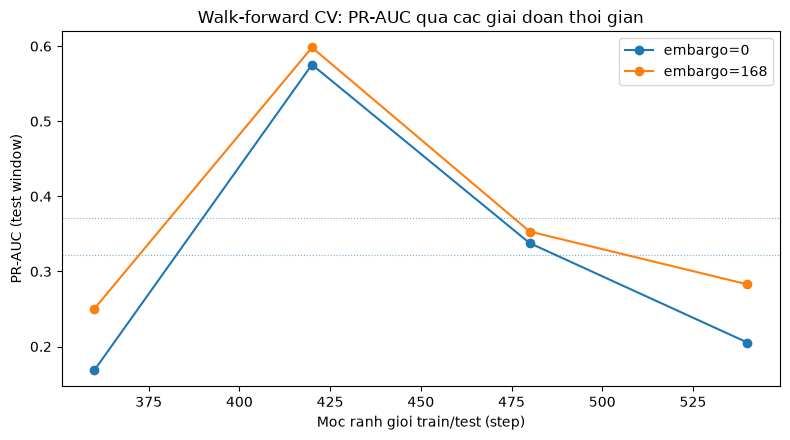

In [10]:
if folds_result is not None and len(folds_result):
    try:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for E, grp in folds_result.groupby("embargo"):
            grp = grp.sort_values("cut")
            ax.plot(grp["cut"], grp["pr_auc"], marker="o", label=f"embargo={E}")
            ax.axhline(grp["pr_auc"].mean(), ls=":", lw=0.8, alpha=0.6)
        ax.set_xlabel("Moc ranh gioi train/test (step)")
        ax.set_ylabel("PR-AUC (test window)")
        ax.set_title("Walk-forward CV: PR-AUC qua cac giai doan thoi gian")
        ax.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN above.")

## Phần D · Phụ thuộc trùng-entity: recipient CŨ (warm) vs MỚI (cold)

📖 Embargo phá phụ thuộc *kề-thời-gian*; **trùng recipient** giữa train/test là loại khác. Trong mỗi fold, chia test làm 2 lát theo `pit_steps_since_last_event` (v3): **warm** (`>0`, recurring, giống train) vs **cold** (`=0`, mới/cold-start). Nếu **PR-AUC(cold) ≪ PR-AUC(warm)** → model dựa nhiều vào tín hiệu recurring-entity → số tổng thể lạc quan cho recipient mới.

In [11]:
entity_result = None
if frame is not None:
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score

    from pit_fintech.models.notebook_lab import walk_forward_folds

    RECENCY_COL = (
        "pit_steps_since_last_event"  # v3: sentinel 999 = khong co prior trong 168h (cold)
    )
    rows = []
    for fold in walk_forward_folds(frame, cuts=CUTS, test_width=TEST_WIDTH, embargo=0):
        if not fold.usable:
            continue
        tr = fold.train
        p = int((tr["isFraud"] == 1).sum())
        n = int((tr["isFraud"] == 0).sum())
        spw = float(np.sqrt(n / max(p, 1)))
        mdl = lgb.LGBMClassifier(scale_pos_weight=spw, **BASELINE_PARAMS, **FIXED)
        mdl.fit(tr[FEATURES], tr["isFraud"])
        te = fold.test.copy()
        te["_p"] = mdl.predict_proba(te[FEATURES])[:, 1]
        for kind, sub in [
            ("warm", te[te[RECENCY_COL] < 999]),
            ("cold", te[te[RECENCY_COL] >= 999]),
        ]:
            y = sub["isFraud"]
            ap = (
                round(float(average_precision_score(y, sub["_p"])), 6)
                if len(sub) and y.nunique() == 2
                else None
            )
            rows.append(
                {
                    "cut": fold.cut,
                    "segment": kind,
                    "rows": len(sub),
                    "fraud": int(y.sum()),
                    "pr_auc": ap,
                }
            )
    entity_result = pd.DataFrame(rows)
    display(entity_result)
    good = entity_result.dropna(subset=["pr_auc"])
    if len(good):
        print(good.groupby("segment")["pr_auc"].agg(["mean", "std", "count"]).round(6))
else:
    print("Skipped: enable RUN above.")

,cut,segment,rows,fraud,pr_auc
0,360,warm,297210,237,0.219727
1,360,cold,53981,445,0.135312
2,420,warm,12214,185,0.477474
3,420,cold,3257,389,0.568414
4,480,warm,22150,190,0.414831
5,480,cold,9868,402,0.276950
6,540,warm,17952,87,0.233488
7,540,cold,31736,493,0.200629


             mean       std  count
segment                           
cold     0.295326  0.191038      4
warm     0.336380  0.129430      4


📖 **Cell dưới — Log lên MLflow** (`stage=cv`): metric so-model (test) + tóm tắt CV mỗi embargo + mỗi fold một nested run. Experiment `paysim-notebook-modeling`, tag `manifest_backed=false`.

In [12]:
if LOG_TO_MLFLOW and proba and folds_result is not None and len(folds_result):
    from pit_fintech.models.notebook_lab import MLFLOW_LAB_TAGS, configure_lab_mlflow

    mlflow = configure_lab_mlflow()
    if mlflow is None:
        print("mlflow not in kernel -> skipped.")
    else:
        yval = splits["val"]["isFraud"].to_numpy()
        with mlflow.start_run(run_name="nb10-compare-cv"):
            mlflow.set_tags(
                {**MLFLOW_LAB_TAGS, "stage": "cv", "notebook": "10_walkforward_cv_split"}
            )
            mlflow.log_params(
                {
                    "seed": SEED,
                    "features": ",".join(FEATURES),
                    "cuts": str(CUTS),
                    "test_width": TEST_WIDTH,
                    "embargos": str(EMBARGOS),
                    **{f"base_{k}": v for k, v in BASELINE_PARAMS.items()},
                }
            )
            for m in proba:
                for k, v in threshold_free(yval, proba[m]["val"]).items():
                    mlflow.log_metric(f"{m}_val_{k}", v)
            for _, r in summary.iterrows():
                e = int(r["embargo"])
                mlflow.log_metric(f"pr_auc_mean_emb{e}", float(r["pr_auc_mean"]))
                mlflow.log_metric(f"pr_auc_std_emb{e}", float(r["pr_auc_std"]))
            for _, r in folds_result.iterrows():
                with mlflow.start_run(
                    nested=True, run_name=f"fold-emb{int(r['embargo'])}-cut{int(r['cut'])}"
                ):
                    mlflow.set_tags({**MLFLOW_LAB_TAGS, "stage": "cv-fold"})
                    mlflow.log_metric("pr_auc", float(r["pr_auc"]))
                    mlflow.log_metric("recall_at_fpr1", float(r["recall_at_fpr1"]))
                    mlflow.log_metric("prevalence", float(r["prevalence"]))
        print("Logged -> nb10 @", mlflow.get_tracking_uri())
else:
    print("MLflow off hoac chua co ket qua.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run fold-emb0-cut360 at: http://100.116.36.6:5000/#/experiments/1/runs/08e04e1353df4392b2d998ec530e83b0
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
🏃 View run fold-emb0-cut420 at: http://100.116.36.6:5000/#/experiments/1/runs/4766bf79e4ae4cac8d37dcd286045ad1
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
🏃 View run fold-emb0-cut480 at: http://100.116.36.6:5000/#/experiments/1/runs/2a8fb84deeac4abcb10d337fa639cf6e
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
🏃 View run fold-emb0-cut540 at: http://100.116.36.6:5000/#/experiments/1/runs/248c005c476b44fbb594ae92a568a2c9
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
🏃 View run fold-emb168-cut360 at: http://100.116.36.6:5000/#/experiments/1/runs/8203443435f646b7b3a7c8c4d8f69d85
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
🏃 View run fold-emb168-cut420 at: http://100.116.36.6:5000/#/experiments/1/runs/1f6c730d9c9f408b9d3b98abc23fc973
🧪 View experime

## Kết luận & bàn giao sang nb11
- **Split & metric:** temporal 3-way là tối thiểu bắt buộc; PR-AUC là số một, đọc kèm prevalence; accuracy bị cấm.
- **LGB vs XGB:** kỳ vọng sát nhau; XGBoost chỉ là learning baseline, **không thay** LightGBM (ADR-003).
- **Walk-forward CV:** đọc **mean ± std** thay vì một điểm. `std` nhỏ → ổn định qua thời gian; `Δ(E=168−0) ≈ 0` → không dựa vào overlap sát ranh giới; **warm/cold** cho biết mức phục vụ recipient mới.
- **Bàn giao:** nb11 (Optuna) tối ưu **PR-AUC trung bình trên chính các walk-forward fold này** (`DEFAULT_CUTS`/`DEFAULT_TEST_WIDTH`). Đó là lý do CV đứng trước tuning. nb12 mới mở TEST.